# CS4350/7350 – Big Data Analytics  
## Phase 1 Starter Notebook: Spark ML Pipeline (Iris Dataset)

### Purpose
This notebook is the **required starter code** for Phase 1. You must use **Apache Spark (PySpark) and Spark ML Pipelines**.

### Important
- You must **build on this notebook** rather than replacing it with a completely different workflow.
- You must use:
  - **Spark DataFrames**
  - **Spark MLlib**
  - **Spark ML Pipelines**
- Using only `pandas`, `scikit-learn`, or non-Spark ML code does **not** satisfy the project requirements.

### What you still must complete
You are expected to:
1. Run the notebook using Spark
2. Review and improve comments where needed
3. Verify all required metrics
4. Add interpretation and discussion
5. Write the 3–4 page report


## Environment Setup

Recommended options:
1. **Databricks Community Edition**
2. **Local PySpark installation**

This starter notebook expects a file named **`iris.csv`** in the same working directory.  
If you are using Databricks, upload `iris.csv` to the workspace or DBFS and update the path below.


In [9]:
# If needed, adjust this path.
# Local example:
DATA_PATH = "iris.csv"

# Databricks example:
# DATA_PATH = "/FileStore/tables/iris.csv"


In [ ]:
# sets JAVA_HOME for Spark to work properly on macOS with Java 21
import os
os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-21.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier,
    LinearSVC,
    NaiveBayes,
    MultilayerPerceptronClassifier,
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Start Spark
spark = SparkSession.builder.appName("CS4350_7350_Phase1_Iris").getOrCreate()
spark


## 1. Load the Dataset into a Spark DataFrame

The project requires the use of a **Spark DataFrame**, not a pandas DataFrame, for the ML workflow.


In [ ]:
# loads the data and shows basic info
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Row count:", df.count())
print("Column count:", len(df.columns))
df.printSchema()
df.show(5, truncate=False)


Row count: 150
Column count: 5
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- label: string (nullable = true)

+------------+-----------+------------+-----------+------+
|sepal_length|sepal_width|petal_length|petal_width|label |
+------------+-----------+------------+-----------+------+
|5.1         |3.5        |1.4         |0.2        |setosa|
|4.9         |3.0        |1.4         |0.2        |setosa|
|4.7         |3.2        |1.3         |0.2        |setosa|
|4.6         |3.1        |1.5         |0.2        |setosa|
|5.0         |3.6        |1.4         |0.2        |setosa|
+------------+-----------+------------+-----------+------+
only showing top 5 rows


## 2. Exploratory Data Analysis (EDA)

Minimum expectations:
- Show the schema
- Show summary statistics
- Show class distribution
- Briefly describe what you observe in your report


In [12]:
# Summary statistics
df.describe().show()

# Class distribution
df.groupBy("label").count().orderBy("label").show()

# Check for nulls
null_counts = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns
])
null_counts.show()


26/04/27 10:51:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+-------------------+------------------+------------------+---------+
|summary|      sepal_length|        sepal_width|      petal_length|       petal_width|    label|
+-------+------------------+-------------------+------------------+------------------+---------+
|  count|               150|                150|               150|               150|      150|
|   mean| 5.843333333333335|  3.057333333333334|3.7580000000000027| 1.199333333333334|     NULL|
| stddev|0.8280661279778637|0.43586628493669793|1.7652982332594662|0.7622376689603467|     NULL|
|    min|               4.3|                2.0|               1.0|               0.1|   setosa|
|    max|               7.9|                4.4|               6.9|               2.5|virginica|
+-------+------------------+-------------------+------------------+------------------+---------+

+----------+-----+
|     label|count|
+----------+-----+
|    setosa|   50|
|versicolor|   50|
| virginica|   50|
+----------+

## 3. Feature Engineering and Label Preparation

We will:
1. Convert the string label into a numeric label
2. Assemble feature columns into a single vector
3. Optionally scale features for models that benefit from scaling


In [ ]:
# Define feature columns and set up transformers
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

label_indexer = StringIndexer(inputCol="label", outputCol="label_index")
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withStd=True, withMean=True)

# Fit transformers needed before splitting if you want a quick prepared DataFrame.
# For a more formal workflow, the estimator should be inside a pipeline.
base_pipeline = Pipeline(stages=[label_indexer, assembler, scaler])
prepared_df = base_pipeline.fit(df).transform(df)

prepared_df.select("label", "label_index", "features_raw", "features_scaled").show(5, truncate=False)


+------+-----------+-----------------+---------------------------------------------------------------------------------+
|label |label_index|features_raw     |features_scaled                                                                  |
+------+-----------+-----------------+---------------------------------------------------------------------------------+
|setosa|0.0        |[5.1,3.5,1.4,0.2]|[-0.8976738791967643,1.0156019907136389,-1.3357516342415199,-1.3110521482051303] |
|setosa|0.0        |[4.9,3.0,1.4,0.2]|[-1.1392004834649512,-0.1315388120502556,-1.3357516342415199,-1.3110521482051303]|
|setosa|0.0        |[4.7,3.2,1.3,0.2]|[-1.3807270877331392,0.3273175090553026,-1.3923992862449772,-1.3110521482051303] |
|setosa|0.0        |[4.6,3.1,1.5,0.2]|[-1.5014903898672336,0.0978893485025235,-1.2791039822380628,-1.3110521482051303] |
|setosa|0.0        |[5.0,3.6,1.4,0.2]|[-1.0184371813308577,1.245030151266418,-1.3357516342415199,-1.3110521482051303]  |
+------+-----------+------------

## 4. Train/Test Split

Use a fixed seed for reproducibility.


In [ ]:
# Split into training and testing sets
train_df, test_df = prepared_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())


Training rows: 126
Testing rows: 24


## 5. Approved Spark Models

You must implement **at least six** different Spark-compatible classification models.

Approved model pool:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- GBT Classifier
- Linear SVM
- Naive Bayes
- Multilayer Perceptron Classifier

Note:
- **GBTClassifier** in Spark supports binary classification only.
- The Iris dataset has **3 classes**, so GBT is not directly appropriate here.
- To keep the starter notebook aligned with Spark capabilities, this notebook trains **six multiclass-compatible models** by default and explains the GBT limitation.


In [15]:
# Multiclass-compatible models for the Iris dataset
models = {
    "Logistic Regression": LogisticRegression(labelCol="label_index", featuresCol="features_scaled", maxIter=100),
    "Decision Tree": DecisionTreeClassifier(labelCol="label_index", featuresCol="features_raw"),
    "Random Forest": RandomForestClassifier(labelCol="label_index", featuresCol="features_raw", numTrees=100, seed=42),
    "Linear SVM (One-vs-Rest)": None,  # created below because it uses a wrapper
    "Naive Bayes": NaiveBayes(labelCol="label_index", featuresCol="features_raw", modelType="multinomial"),
    "Multilayer Perceptron": MultilayerPerceptronClassifier(
        labelCol="label_index",
        featuresCol="features_scaled",
        maxIter=200,
        layers=[4, 8, 6, 3],
        seed=42
    ),
}


In [16]:
from pyspark.ml.classification import OneVsRest

# LinearSVC is binary; OneVsRest makes it usable for multiclass classification.
svm_classifier = LinearSVC(labelCol="label_index", featuresCol="features_scaled", maxIter=100)
models["Linear SVM (One-vs-Rest)"] = OneVsRest(
    labelCol="label_index",
    featuresCol="features_scaled",
    classifier=svm_classifier
)

# Important note about GBT
print("GBTClassifier is not included in the training loop below because Spark GBTClassifier is for binary classification.")
print("For this Iris starter notebook, use the six multiclass-compatible models shown above.")


GBTClassifier is not included in the training loop below because Spark GBTClassifier is for binary classification.
For this Iris starter notebook, use the six multiclass-compatible models shown above.


## 6. Train and Evaluate Models

Required metrics:
- Accuracy
- Precision
- Recall
- F1-score

The comparison table below helps satisfy the model comparison requirement.


In [ ]:
# Define evaluation metrics
evaluators = {
    "accuracy": MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="prediction", metricName="accuracy"),
    "f1": MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="prediction", metricName="f1"),
    "weightedPrecision": MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="prediction", metricName="weightedPrecision"),
    "weightedRecall": MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="prediction", metricName="weightedRecall"),
}

# Train, predict, and evaluate each model
results = []
predictions_dict = {}

for model_name, estimator in models.items():
    model = estimator.fit(train_df)
    preds = model.transform(test_df)
    predictions_dict[model_name] = preds

    row = {
        "model": model_name,
        "accuracy": evaluators["accuracy"].evaluate(preds),
        "f1": evaluators["f1"].evaluate(preds),
        "precision": evaluators["weightedPrecision"].evaluate(preds),
        "recall": evaluators["weightedRecall"].evaluate(preds),
    }
    results.append(row)

# Display results sorted by accuracy
results_df = spark.createDataFrame(results).orderBy(F.desc("accuracy"))
results_df.show(truncate=False)


26/04/27 10:52:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/27 10:53:07 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:07 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:09 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:10 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:10 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:10 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:11 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:11 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:11 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:53:12 ERROR OWLQN: Failure! Resetting history: breeze.optimize.NaNHistory: 
26/04/27 10:5

+------------------+------------------+------------------------+------------------+------------------+
|accuracy          |f1                |model                   |precision         |recall            |
+------------------+------------------+------------------------+------------------+------------------+
|1.0               |1.0               |Linear SVM (One-vs-Rest)|1.0               |1.0               |
|1.0               |1.0               |Decision Tree           |1.0               |1.0               |
|1.0               |1.0               |Random Forest           |1.0               |1.0               |
|1.0               |1.0               |Logistic Regression     |1.0               |1.0               |
|1.0               |1.0               |Naive Bayes             |1.0               |1.0               |
|0.9583333333333334|0.9578282828282827|Multilayer Perceptron   |0.9635416666666665|0.9583333333333333|
+------------------+------------------+------------------------+---------

## 7. Confusion Matrices for At Least Two Models

The project requires a confusion matrix for at least two models.


In [18]:
def show_confusion_matrix(preds, title):
    print(f"\nConfusion Matrix: {title}")
    (
        preds.groupBy("label_index", "prediction")
        .count()
        .orderBy("label_index", "prediction")
        .show()
    )

# Show confusion matrices for two example models
show_confusion_matrix(predictions_dict["Logistic Regression"], "Logistic Regression")
show_confusion_matrix(predictions_dict["Random Forest"], "Random Forest")



Confusion Matrix: Logistic Regression
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|   11|
|        1.0|       1.0|    6|
|        2.0|       2.0|    7|
+-----------+----------+-----+


Confusion Matrix: Random Forest
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|   11|
|        1.0|       1.0|    6|
|        2.0|       2.0|    7|
+-----------+----------+-----+



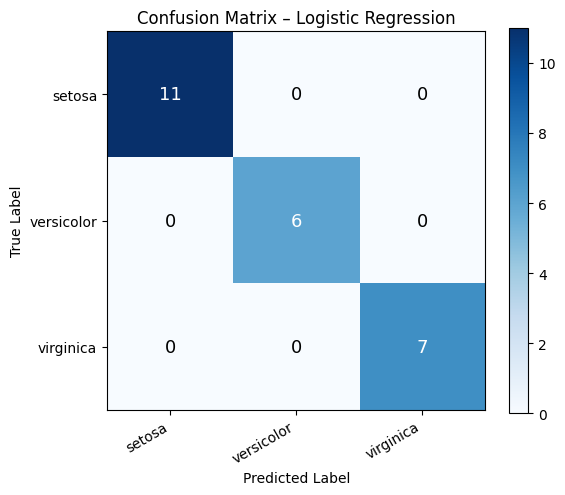

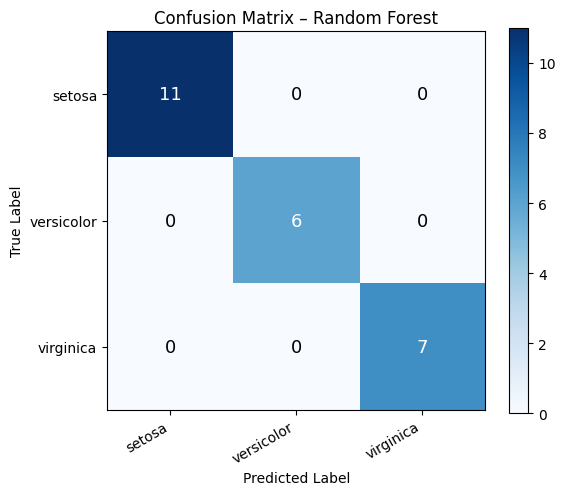

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot confusion matrix from Spark DataFrame predictions
def plot_confusion_matrix(preds_df, model_name):
    # Convert confusion matrix data to pandas for plotting
    cm_pdf = (
        preds_df.groupBy("label_index", "prediction")
        .count()
        .orderBy("label_index", "prediction")
        .toPandas()
    )
    # Create a 3x3 confusion matrix array
    cm_array = np.zeros((3, 3), dtype=int)
    for _, row in cm_pdf.iterrows():
        i = int(row["label_index"])
        j = int(row["prediction"])
        cm_array[i][j] = int(row["count"])
    
    # Plotting the confusion matrix
    class_names = ["setosa", "versicolor", "virginica"]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_array, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(3)); ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticks(range(3)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Confusion Matrix – {model_name}")
    
    # Add text annotations
    thresh = cm_array.max() / 2
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm_array[i, j]), ha="center", va="center",
                    color="white" if cm_array[i, j] > thresh else "black", fontsize=13)
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for two example models
plot_confusion_matrix(predictions_dict["Logistic Regression"], "Logistic Regression")
plot_confusion_matrix(predictions_dict["Random Forest"], "Random Forest")

## 8. Convert Results to a Local Table for Plotting

Small result tables can be converted locally for plotting.
This does **not** violate the Spark requirement because the ML workflow itself remains in Spark.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert Spark DataFrame to Pandas for plotting
plot_df = results_df.toPandas()
plot_df


,accuracy,f1,model,precision,recall
0,1.000000,1.000000,Logistic Regression,1.000000,1.000000
1,1.000000,1.000000,Decision Tree,1.000000,1.000000
2,1.000000,1.000000,Random Forest,1.000000,1.000000
3,1.000000,1.000000,Linear SVM (One-vs-Rest),1.000000,1.000000
4,1.000000,1.000000,Naive Bayes,1.000000,1.000000
5,0.958333,0.957828,Multilayer Perceptron,0.963542,0.958333


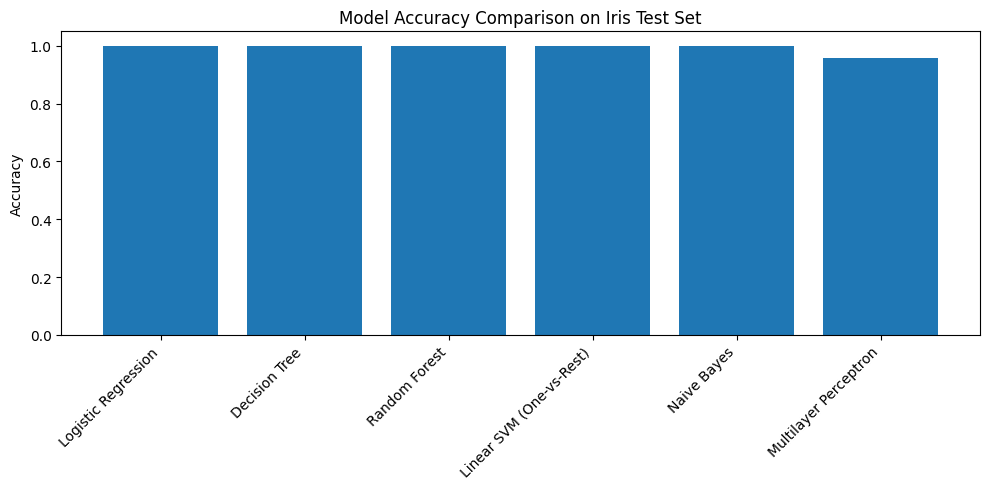

In [20]:
# Simple comparison chart
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison on Iris Test Set")
plt.tight_layout()
plt.show()


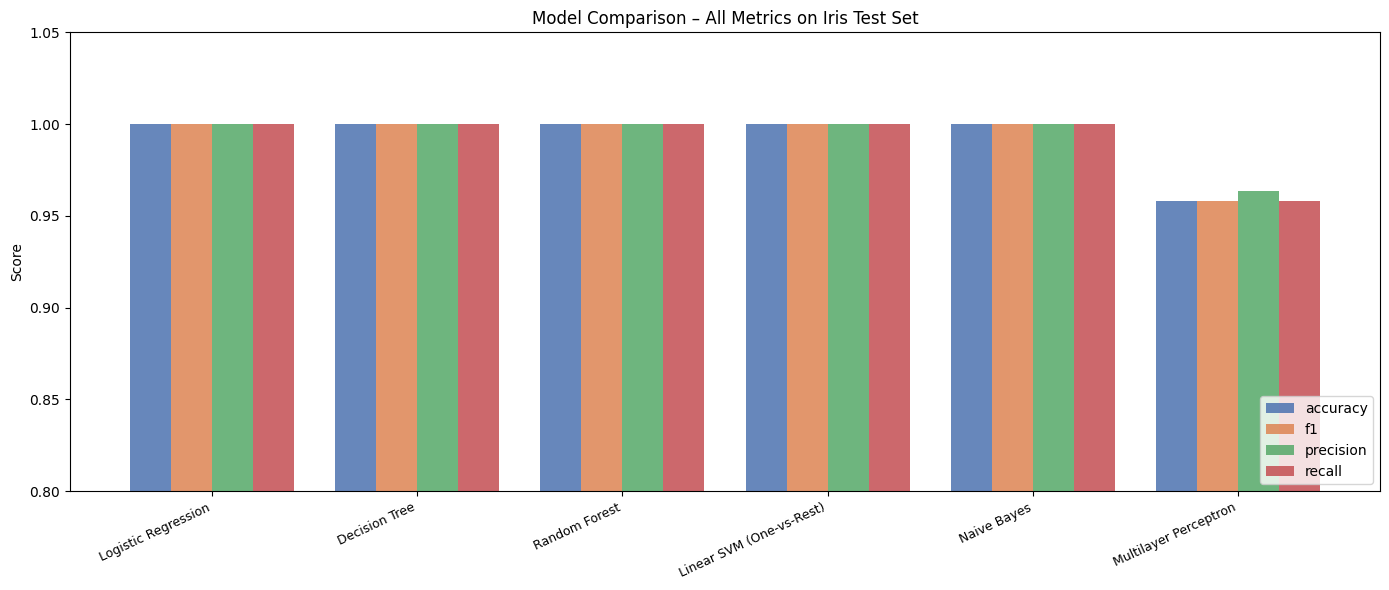

In [ ]:
# Grouped bar chart comparing all 4 metrics across all models
import numpy as np

# Define metrics and colors for the plot
metrics = ["accuracy", "f1", "precision", "recall"]
model_names = plot_df["model"].tolist()
x = np.arange(len(model_names))
width = 0.2
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))
# Create bars for each metric
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, plot_df[metric], width, label=metric, color=color, alpha=0.85)
# Set x-ticks and labels
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0.8, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison – All Metrics on Iris Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Interpretation Notes for Students

In your notebook and report, explain:
- Which model performed best?
    # Five out of six models (Logistic Regression, Decision Tree, Random Forest, Linear SVM, and Naive Bayes) achieved perfect scores of 100% across all metrics. The Multilayer Perceptron was the only model that fell slightly short at 95.8% accuracy.
- Whether the results were close or very different
    # The results were very close overall, with most models clustered at 100%. The only meaningful difference was the MLP scoring slightly lower. This is not surprising given how clean and separable the Iris dataset is.
- Why some models may perform better or worse
    # The MLP underperformed slightly compared to the other models. Neural networks generally require more data to generalize well — with only 126 training samples, the MLP may not have had enough data to fully optimize its weights. Tree-based models like Decision Tree and Random Forest handle small datasets more naturally.
- Whether scaling appears to matter
    # Yes. Models like Logistic Regression, SVM, and MLP use features_scaled because they rely on gradient-based optimization or distance calculations, which are sensitive to feature magnitude. Tree-based models and Naive Bayes use features_raw since they are not affected by scale.

- Any limitations of the dataset or workflow
    # The Iris dataset is very small (150 samples) and clean, which makes it easy for most models to achieve near-perfect accuracy. The 24-sample test set means results can vary significantly across different random splits. Real-world datasets in Phase 2 will likely show more meaningful differences between models.

You should not only show numbers; you should also interpret them.


## 10. Required Report Reminder

Your report should summarize:
1. The workflow you used
2. The Spark pipeline components
3. The models you trained
4. The evaluation results
5. Your discussion and conclusions


## 11. Important Reminder About Phase 2

You are strongly encouraged to reuse and extend this Phase 1 Spark pipeline in Phase 2.


## 12. Checklist Before Submission

- [ ] Used Spark DataFrames
- [ ] Used Spark ML Pipeline components
- [ ] Trained at least 6 approved models
- [ ] Reported accuracy, precision, recall, and F1
- [ ] Included confusion matrices for at least 2 models
- [ ] Compared models in a table or figure
- [ ] Wrote clear comments in the notebook
- [ ] Prepared the 3–4 page report
